# Import

In [5]:
import re
from datetime import datetime
import time
import requests
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

# Dataset load

## Prepare dataset

In [123]:
df = pd.read_csv('datasets/dedust_dataset.csv')
df.head()

,token_address,project,pool_address,pool_deployment_at,pool_first_tx_sender,min_pool_info_time,avg_5min_lp_fee,avg_5min_protocol_fee,avg_5min_referral_fee,initial_tvl_usd,...,price_min_5min,price_max_hour,price_min_hour,alice_rugpull_60min,alice_rugpull_120min,alice_rugpull_180min,alice_rugpull_240min,alice_rugpull_300min,alice_rugpull_360min,alice_rugpull_420min
0,0:429592B9BA8537158ED237706C7505E753F0C779DB72...,ton.fun,0:429592B9BA8537158ED237706C7505E753F0C779DB72...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.735965e-07,4.763351e-07,4.735965e-07,12,12,12,12,12,12,12
1,0:E64C3D812EE0B4B8E511D1D6253244304217068322F2...,ton.fun,0:E64C3D812EE0B4B8E511D1D6253244304217068322F2...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.735975e-07,4.735975e-07,4.735975e-07,0,0,0,0,0,0,0
2,0:36C39A24447269B69F5D960D720E567DEDDC1AAC1E5F...,ton.fun,0:36C39A24447269B69F5D960D720E567DEDDC1AAC1E5F...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.739716e-07,4.753972e-07,4.651918e-07,2,2,2,2,2,2,2
3,0:835E2DFA2EEE10FE6515BF2512A17B4495B606A0EFB8...,ton.fun,0:835E2DFA2EEE10FE6515BF2512A17B4495B606A0EFB8...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.029170e-06,1.050064e-06,1.029170e-06,0,0,0,0,0,0,0
4,0:B6F2F59EA5B7B367912318440335A3EFF2288FEC77E9...,ton.fun,0:B6F2F59EA5B7B367912318440335A3EFF2288FEC77E9...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.753784e-07,4.753784e-07,4.753784e-07,6,6,6,6,6,6,6


In [124]:
df.describe(include='all')

,token_address,project,pool_address,pool_deployment_at,pool_first_tx_sender,min_pool_info_time,avg_5min_lp_fee,avg_5min_protocol_fee,avg_5min_referral_fee,initial_tvl_usd,...,price_min_5min,price_max_hour,price_min_hour,alice_rugpull_60min,alice_rugpull_120min,alice_rugpull_180min,alice_rugpull_240min,alice_rugpull_300min,alice_rugpull_360min,alice_rugpull_420min
count,373321,373321,373321,32499,32499,32499,30301.000000,30301.000000,0.0,32499.000000,...,3.733210e+05,3.733210e+05,3.733210e+05,3.733210e+05,3.733210e+05,3.733210e+05,3.733210e+05,3.733210e+05,3.733210e+05,3.733210e+05
unique,373186,3,373321,32286,12,32135,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,0:2C510107254C7E96B00DD0887C5EEB0963D27769BD15...,ton.fun,0:429592B9BA8537158ED237706C7505E753F0C779DB72...,2024-07-21 15:54:20.000 UTC,0:5F0564FB5F604783DB57031CE1CF668A88D4D4D6DA6D...,2024-07-10 10:16:36.000 UTC,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,314648,1,3,32407,3,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,0.002676,0.000669,NaN,1633.196079,...,3.747939e+04,5.954881e+05,2.994654e+04,5.340226e+01,5.159898e+01,5.038242e+01,4.947722e+01,4.874746e+01,4.812120e+01,4.757222e+01
std,NaN,NaN,NaN,NaN,NaN,NaN,0.000595,0.000149,NaN,8208.648377,...,7.448977e+06,1.699039e+08,6.506184e+06,6.089719e+03,6.087161e+03,6.084716e+03,6.082373e+03,6.080096e+03,6.078286e+03,6.076674e+03
min,NaN,NaN,NaN,NaN,NaN,NaN,0.000400,0.000100,NaN,0.000000,...,2.800843e-28,1.367385e-27,2.001001e-29,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,NaN,NaN,NaN,NaN,NaN,NaN,0.002000,0.000500,NaN,0.000000,...,4.735786e-07,4.736909e-07,4.657499e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,NaN,NaN,NaN,NaN,NaN,NaN,0.003200,0.000800,NaN,0.000000,...,4.737844e-07,4.744692e-07,4.735973e-07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,NaN,NaN,NaN,NaN,NaN,NaN,0.003200,0.000800,NaN,711.423885,...,4.758463e-07,5.079925e-07,4.744405e-07,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00


In [125]:
df['target'] = df['alice_rugpull_60min'].apply(lambda x: 1 if x == 0 else 0)
df['first_buy_time'] = pd.to_datetime(df['first_buy_time'])
df['first_sell_time'] = pd.to_datetime(df['first_sell_time'])
df['pool_deployment_at'] = pd.to_datetime(df['pool_deployment_at'])
df['jetton_deployment_at'] = pd.to_datetime(df['jetton_deployment_at'])
df['min_pool_info_time'] = pd.to_datetime(df['min_pool_info_time'])
df['first_trade_time'] = df[['first_buy_time','first_sell_time']].apply(lambda x: min(x), axis=1)
df = df.drop(['pool_address', 'avg_5min_referral_fee', 'alice_rugpull_60min', 'alice_rugpull_120min', 'alice_rugpull_180min',
       'alice_rugpull_240min', 'alice_rugpull_300min', 'alice_rugpull_360min',
       'alice_rugpull_420min'], axis=1)
print(df.columns)

Index(['token_address', 'project', 'pool_deployment_at',
       'pool_first_tx_sender', 'min_pool_info_time', 'avg_5min_lp_fee',
       'avg_5min_protocol_fee', 'initial_tvl_usd', 'max_tvl_5min',
       'min_tvl_5min', 'tvl_hour', 'jetton_deployment_at',
       'jetton_first_tx_sender', 'symbol', 'decimals', 'buys_cnt', 'buys_5min',
       'total_usd_buy_volume', 'total_usd_buy_volume_5min', 'unique_buyers',
       'unique_buyers_5min', 'first_buy_time', 'initial_buy_price',
       'sells_cnt', 'sells_5min', 'total_usd_sell_volume',
       'total_usd_sell_volume_5min', 'unique_sellers', 'unique_sellers_5min',
       'first_sell_time', 'initial_sell_price', 'initial_price',
       'price_max_5min', 'price_min_5min', 'price_max_hour', 'price_min_hour',
       'target', 'is_pool_creator', 'first_trade_time'],
      dtype='object')


In [126]:
df.isna().sum() / len(df) * 100

token_address                  0.000000
project                        0.000000
pool_deployment_at            91.294623
pool_first_tx_sender          91.294623
min_pool_info_time            91.294623
avg_5min_lp_fee               91.883393
avg_5min_protocol_fee         91.883393
initial_tvl_usd               91.294623
max_tvl_5min                  91.883393
min_tvl_5min                  91.883393
tvl_hour                      91.465254
jetton_deployment_at           0.000000
jetton_first_tx_sender         0.000000
symbol                         0.078485
decimals                       7.339528
buys_cnt                       0.000000
buys_5min                      0.000000
total_usd_buy_volume           0.000000
total_usd_buy_volume_5min      0.000000
unique_buyers                  0.000000
unique_buyers_5min             0.000000
first_buy_time                 0.027054
initial_buy_price              0.027054
sells_cnt                      0.000000
sells_5min                     0.000000


In [54]:
print(f"{float(df['target'].sum()/len(df)) * 100:.3}% rugpulls for 60 minutes frame ")
print(f'len of df: {len(df)}')

55.5% rugpulls for 60 minutes frame 
len of df: 373321


## Add Alice columns

In [137]:
df['count_tx_5min'] = df['buys_5min'] + df['sells_5min']
df['buy_perc_5min'] = df['buys_5min']/df['count_tx_5min']
df['sell_perc_5min'] = df['sells_5min']/df['count_tx_5min']
df['total_usd_volume_5min'] = df['total_usd_buy_volume_5min'] + df['total_usd_sell_volume_5min']
for col in ['pool_deployment_at', 'jetton_deployment_at']:
    df[f'{col}_month'] = pd.to_datetime(df[col]).dt.month
df['jetton_creation_year'] = pd.to_datetime(df['jetton_deployment_at']).dt.year
df['jetton_creation_trade_delta'] = (df['first_trade_time'] - df['jetton_deployment_at']).dt.seconds
df['pool_creation_trade_delta'] = (df['first_trade_time'] - df['pool_deployment_at']).dt.seconds
df['is_pool_creator'] = df['pool_first_tx_sender'] == df['jetton_first_tx_sender']


# Learn

In [138]:

# Функции для циклического кодирования
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

In [143]:
# обучаемся только на дедасте
df = df[df['project'] == 'dedust']

Model: Random Forest
CV Mean AUC: 0.7895
Test AUC: 0.7876
Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.48      0.57      2204
           1       0.77      0.89      0.83      4414

    accuracy                           0.76      6618
   macro avg       0.73      0.69      0.70      6618
weighted avg       0.75      0.76      0.74      6618



Model: Gradient Boosting
CV Mean AUC: 0.7952
Test AUC: 0.7856
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.45      0.55      2204
           1       0.77      0.90      0.83      4414

    accuracy                           0.75      6618
   macro avg       0.73      0.68      0.69      6618
weighted avg       0.75      0.75      0.74      6618





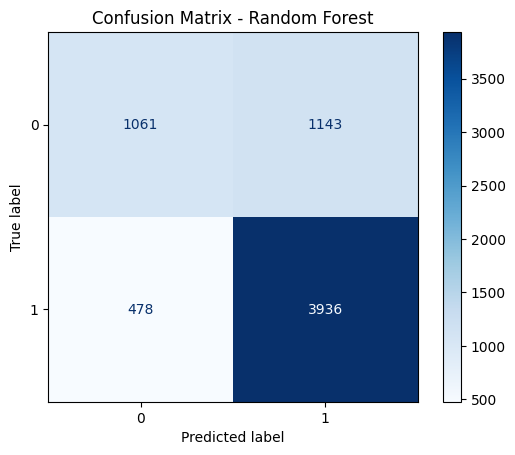

In [144]:
# Определение типов признаков
categorical_features = [
    'project'
]
numerical_features = [
    'buys_5min', # buys_cnt
    'sells_5min', # count_tx - buys_cnt
    'buy_perc_5min', # purchase percentage
    'sell_perc_5min', # sale-percentage
    'unique_buyers_5min', # unique buyers
    'unique_sellers_5min', # unique sellers
    'total_usd_volume_5min', # total eth_value
    'total_usd_buy_volume_5min', 
    'total_usd_sell_volume_5min', # sell_eth_value
    'jetton_creation_year', # creation-year
    'decimals', # decimals
    'avg_5min_lp_fee', # tax buy, tax sell
    'avg_5min_protocol_fee', # tax buy, tax sell
    'jetton_creation_trade_delta', # creation trade_delta
    'pool_creation_trade_delta', # creation pool delta
    'is_pool_creator', # is-pool creator
    'initial_tvl_usd', # Initial supply of tokens
    'initial_price', # initial price

    'initial_buy_price', 
    'max_tvl_5min', 
    'min_tvl_5min',
    
    'initial_sell_price', 
    'price_max_5min', 
    'price_min_5min',
]
cyclical_features = [
    'pool_deployment_at_month', # creation month sin/cos
    'jetton_deployment_at_month' # creation month sin/cos
]

# Разделение данных
X = df[categorical_features + numerical_features + cyclical_features]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('cycl_sin', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('sin', sin_transformer(12))
        ]), cyclical_features),
        ('cycl_cos', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('cos', cos_transformer(12))
        ]), cyclical_features)
    ]
)

# Выбор и настройка моделей
models = {
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', 
        n_jobs=-1,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

# Обучение и оценка
results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Кросс-валидация
    cv = StratifiedKFold(n_splits=3)
    cv_scores = cross_val_score(
        pipeline, X_train, y_train, 
        cv=cv, scoring='roc_auc', n_jobs=-1
    )
    
    # Обучение на полном train
    pipeline.fit(X_train, y_train)
    
    # Предсказания
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:,1]
    
    # Сохранение результатов
    results[name] = {
        'cv_mean_auc': cv_scores.mean(),
        'test_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'model': pipeline
    }

# Вывод результатов
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"CV Mean AUC: {metrics['cv_mean_auc']:.4f}")
    print(f"Test AUC: {metrics['test_auc']:.4f}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация матрицы ошибок для лучшей модели
best_model = max(results, key=lambda x: results[x]['test_auc'])
cm = confusion_matrix(y_test, results[best_model]['model'].predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix - {best_model}')
plt.show()


In [145]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (train_test_split, 
                                   StratifiedKFold,
                                   GridSearchCV)
from sklearn.preprocessing import (StandardScaler, 
                                 OrdinalEncoder,
                                 FunctionTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (RandomForestClassifier,
                            GradientBoostingClassifier,
                            AdaBoostClassifier,
                            ExtraTreesClassifier)
from sklearn.metrics import (roc_auc_score, 
                           classification_report, 
                           confusion_matrix,
                           ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

# Инициализация функций для циклического кодирования
def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

def cos_transformer(period):
    return FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))

# Конвейер предобработки
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

cyclical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('sin', sin_transformer(12)),
    ('cos', cos_transformer(12))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('cycl', cyclical_transformer, cyclical_features)
    ]
)

# Настройка моделей и гиперпараметров
models_config = {
    'RandomForest': {
        'model': RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        'params': {
            'classifier__n_estimators': [200, 300],
            'classifier__max_depth': [None, 15],
            'classifier__min_samples_split': [2, 5],
            'classifier__max_features': ['sqrt', 0.8]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(
            use_label_encoder=False, 
            eval_metric='logloss',
            scale_pos_weight=0.82,
            random_state=42,
            n_jobs=-1
        ),
        'params': {
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [5, 7],
            'classifier__subsample': [0.8, 1.0],
            'classifier__colsample_bytree': [0.8, 1.0]
        }
    },
    'GradientBoosting': {
        'model': GradientBoostingClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [200, 300],
            'classifier__learning_rate': [0.05, 0.1],
            'classifier__max_depth': [3, 5],
            'classifier__subsample': [0.8, 1.0]
        }
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'classifier__n_estimators': [100, 200],
            'classifier__learning_rate': [0.5, 1.0]
        }
    }
}

# Обучение и оптимизация
results = {}
for model_name, config in models_config.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', config['model'])
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config['params'],
        scoring='roc_auc',
        cv=StratifiedKFold(n_splits=3),
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    y_proba = best_model.predict_proba(X_test)[:, 1]
    
    results[model_name] = {
        'best_params': grid_search.best_params_,
        'best_score': grid_search.best_score_,
        'test_auc': roc_auc_score(y_test, y_proba),
        'report': classification_report(y_test, y_pred),
        'model': best_model
    }

# Анализ результатов
for model_name, metrics in results.items():
    print(f"Model: {model_name}")
    print(f"Best CV AUC: {metrics['best_score']:.4f}")
    print(f"Test AUC: {metrics['test_auc']:.4f}")
    print("Best Parameters:")
    for param, value in metrics['best_params'].items():
        print(f"  {param}: {value}")
    print("Classification Report:")
    print(metrics['report'])
    print("\n" + "="*80 + "\n")

# Визуализация лучшей модели
best_model_name = max(results, key=lambda x: results[x]['test_auc'])
cm = confusion_matrix(y_test, results[best_model_name]['model'].predict(X_test))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f'Best Model: {best_model_name}')
plt.show()


XGBoostError: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Users/d.yaremus/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <89AD948E-E564-3266-867D-7AF89D6488F0> /Users/d.yaremus/Library/Python/3.9/lib/python/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.d

In [109]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
        ('cycl_sin', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('sin', sin_transformer(12))
        ]), cyclical_features),
        ('cycl_cos', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('cos', cos_transformer(12))
        ]), cyclical_features)
    ]
)
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['buys_5min', 'sells_5min', 'buy_perc_5min',
                                  'sell_perc_5min', 'unique_buyers_5min',
                                  'unique_sellers_5min',
                                  'total_usd_volume_5min',
                                  'total_usd_buy_volume_5min',
                                  'total_usd_sell_volume_5min',
                                  'initial_buy_price', 'avg_5min_lp_fee'...
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x35ee29670>))]),
                                 ['pool_deployment_at_month',
                                  'jetton_deployment_at_month']),
                                ('cycl_cos',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x3652f8940>))]),
                                 ['pool_deployment_at_month',
                                  'jetton_deployment_at_month'])])

In [107]:
preprocessor.fit_transform(X[:100]).shape

(100, 23)

In [108]:
X.shape

(373321, 23)